В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [160]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


# МНК

In [161]:
y_charges = non_smoker_df['charges'].values
x_age = non_smoker_df['age'].values

In [162]:
x_age_w1 = np.c_[np.ones((x_age.shape[0], 1)), x_age]

In [163]:
def find_theta(X, y):
  theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y) 
  return theta

In [164]:
b_age, w_age = find_theta(x_age_w1, y_charges)

In [165]:
charges_predicted_mnk = w_age * x_age + b_age
display(charges_predicted_mnk)

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [166]:
def rmse (y, y_predicted):
    rmse = np.sqrt(np.mean(np.square(y_predicted - y)))
    return rmse

In [167]:
rmse(y_charges, charges_predicted_mnk)

np.float64(4662.505766636395)

# `scikit-learn.LinearRegression`

In [168]:
from sklearn.linear_model import LinearRegression

In [169]:
lin_reg = LinearRegression()

In [170]:
lin_reg.fit(x_age_w1, y_charges)

LinearRegression()

In [171]:
lin_reg.intercept_

np.float64(-2091.420556565028)

In [172]:
w0, w1 = lin_reg.coef_

In [173]:
y_sk_predicted = w1 * x_age + lin_reg.intercept_

In [174]:
rmse(y_charges, y_sk_predicted)

np.float64(4662.505766636395)

# Full-Batch градієнтного спуску

In [175]:
def ful_batch(y, x, lr, epochs):
    m, b = 0, 0
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_predicted = m * x + b
        error = y_predicted - y
        loss = (error**2).mean()
        errors.append(loss)
        m_der = (1/n) * error.dot(x)
        b_der = (1/n) * sum(error)
        m -= lr * m_der
        b -= lr * b_der
    return m, b, errors

In [176]:
m_age, b_age, errors = ful_batch(y_charges, x_age, 0.0001, 5000) 

In [177]:
charges_predicted_fb_best = m_age * x_age + b_age

In [178]:
rmse(y_charges, charges_predicted_fb_best) #найкращий

np.float64(4709.934748280125)

In [179]:
m_age, b_age, errors = ful_batch(y_charges, x_age, 0.000001, 1000)
charges_predicted = m_age * x_age + b_age
rmse_score = rmse(y_charges, charges_predicted)
print(rmse_score)

4978.759310128403


In [180]:
m_age, b_age, errors = ful_batch(y_charges, x_age, 0.00001, 1000)
charges_predicted = m_age * x_age + b_age
rmse_score = rmse(y_charges, charges_predicted)
print(rmse_score)

4715.468868837915


Text(0, 0.5, 'error')

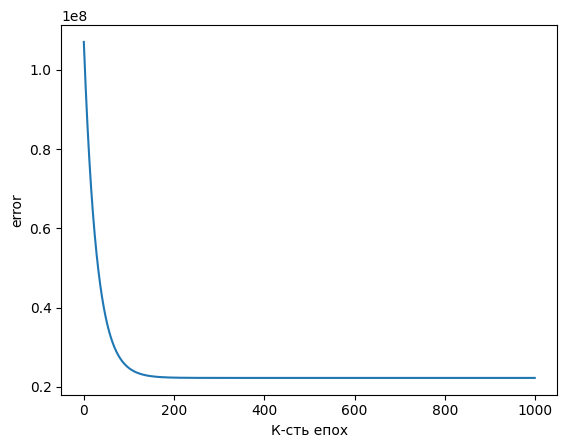

In [181]:
plt.plot(errors)
plt.xlabel('К-сть епох')
plt.ylabel('error')

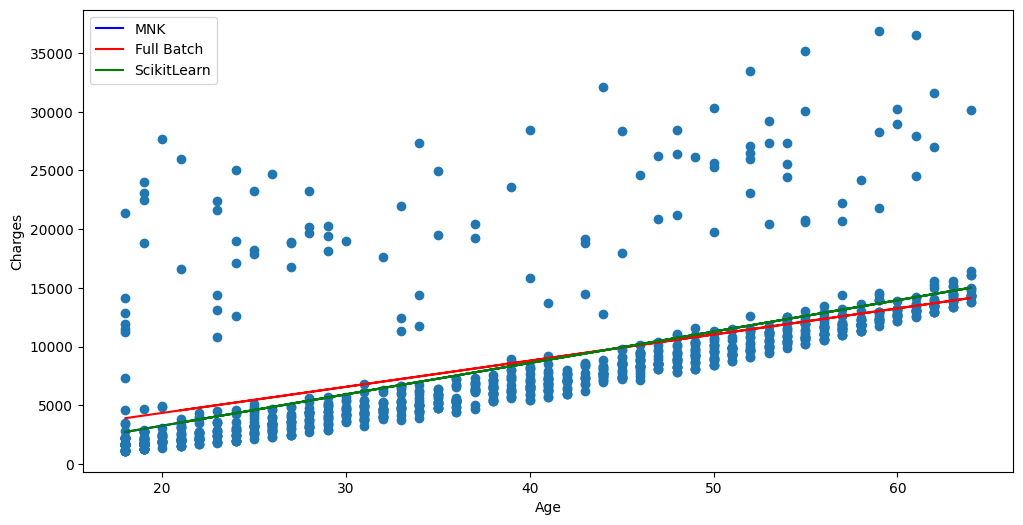

In [182]:
plt.figure(figsize=(12, 6))
plt.scatter(x_age, y_charges)
plt.plot(x_age, charges_predicted_mnk, color = 'blue', label='MNK')
plt.plot(x_age, charges_predicted_fb_best, color = 'red', label='Full Batch')
plt.plot(x_age, y_sk_predicted, color = 'green', label='ScikitLearn')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.show()

* На графіку ми бачимо, що лінійна регресія, яка створена за допомогою Scikit-learn, є найкращою.
* На мою думку, метод найменших квадратів показав найгірший результат, а градієнтний спуск опинився десь посередині.
* За помилками теж можна побачити, що найменшу помилку і найменші втрати показує саме Scikit-learn. А найбільшу помилку видає метод найменших квадратів. 
* При цьому мої припущення щодо коефіцієнтів виявилися досить наближеними до реальності, там помилка становить лише 200 доларів.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [183]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [184]:
x_age_smoker = smoker_df['age'].values

In [185]:
y_charges_smoker = smoker_df['charges'].values

In [186]:
# x_age_smoker_w1 = np.c_[np.ones((x_age_smoker.shape[0], 1)), x_age_smoker]

In [188]:
lin_reg_smoker = LinearRegression()

In [189]:
lin_reg_smoker.fit(x_age_smoker_df, y_charges_smoker)

LinearRegression()

In [196]:
y_smoker_predicted = lin_reg_smoker.predict(x_age_smoker_df)

In [201]:
rmse(y_charges_smoker, y_smoker_predicted)

np.float64(10711.00334810241)

In [213]:
r2 = 1 - ((sum((y_charges_smoker - y_smoker_predicted)**2)) / sum((y_charges_smoker - y_charges_smoker.mean())**2))

In [214]:
w = lin_reg_smoker.coef_[0]
b = lin_reg.intercept_
print(f'Коєфіцієнти: w = {w}, b = {b}, r^2 = {r2}')

Коєфіцієнти: w = 305.23760210982874, b = -2091.420556565028, r^2 = 0.13558924096084057


Text(0, 0.5, 'Charges')

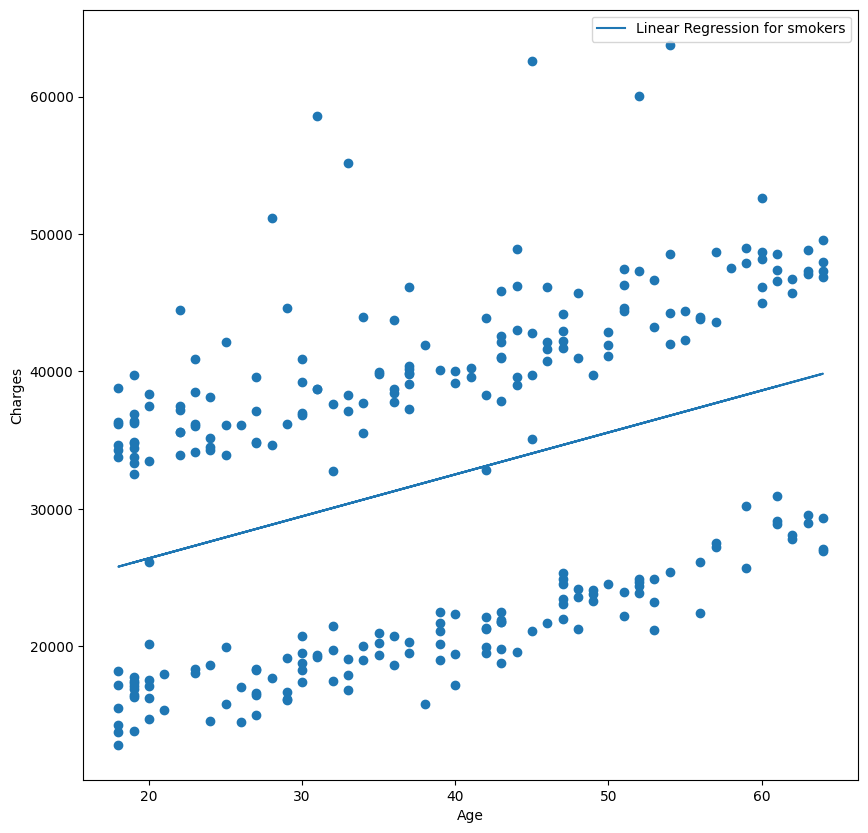

In [202]:
plt.figure(figsize=(10, 10))
plt.scatter(x_age_smoker, y_charges_smoker)
plt.plot(x_age_smoker, y_smoker_predicted, label='Linear Regression for smokers')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Charges')

* На графіку можемо побачити що в нас дані розподілені на дві частини наша лінійна регресія є посередині.На мою думку вона тут недоцільна.
* Також наша аналіз точності показав результат 0,13 що свідчить що модель не пояснює жодної варіабельності реагуючих даних.
Тому я б її не використовувала.